# Energy Conservation in Chaotic Systems: Hénon-Heiles Integrator Comparison

This notebook explores the energy conservation properties of different numerical integrators when applied to the Hénon-Heiles system, a classic example of a Hamiltonian system exhibiting chaotic behavior. We will implement and compare the Euler method, the Runge-Kutta 4 (RK4) method, and a Symplectic integrator. The goal is to observe how accurately each method preserves the total energy of the system over extended simulation periods and to highlight the advantages of symplectic integration for Hamiltonian dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Hénon-Heiles potential and its derivatives
def V(x, y):
    return 0.5 * (x**2 + y**2) + x**2 * y - (1/3) * y**3

def dVdx(x, y):
    return x + 2 * x * y

def dVdy(x, y):
    return y + x**2 - y**2

# Define the Hamiltonian (total energy)
def H(x, y, px, py):
    # H = T + V
    # T = 0.5 * (px^2 + py^2) assuming m=1
    return 0.5 * (px**2 + py**2) + V(x, y)

Now, let's implement the numerical integrators: Euler, Runge-Kutta 4 (RK4), and a Symplectic (Leapfrog/Verlet) integrator. The Hénon-Heiles equations of motion are given by:

$\dot{x} = p_x$
$\dot{y} = p_y$
$\dot{p_x} = -\frac{\partial V}{\partial x}$
$\dot{p_y} = -\frac{\partial V}{\partial y}$

For a general system $\dot{\mathbf{q}} = \mathbf{f}(\mathbf{q}, t)$, where $\mathbf{q} = (x, y, p_x, p_y)$, we can write the derivatives.

In [2]:
# Define the derivatives function for the integrators
def derivatives(state):
    x, y, px, py = state
    dqxdt = px
    dqydt = py
    dpxdt = -dVdx(x, y)
    dpydt = -dVdy(x, y)
    return np.array([dqxdt, dqydt, dpxdt, dpydt])

# Euler method
def euler_step(state, dt):
    return state + dt * derivatives(state)

# RK4 method
def rk4_step(state, dt):
    k1 = derivatives(state)
    k2 = derivatives(state + 0.5 * dt * k1)
    k3 = derivatives(state + 0.5 * dt * k2)
    k4 = derivatives(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Symplectic (Leapfrog/Velocity Verlet) integrator
# For this system, we can separate position and momentum updates.
# This specific implementation is a second-order symplectic integrator for Hamiltonian systems.
def symplectic_step(state, dt):
    x, y, px, py = state

    # Half-step for momentum (kick)
    px_half = px - 0.5 * dt * dVdx(x, y)
    py_half = py - 0.5 * dt * dVdy(x, y)

    # Full-step for position (drift)
    x_new = x + dt * px_half
    y_new = y + dt * py_half

    # Half-step for momentum (kick) with new positions
    px_new = px_half - 0.5 * dt * dVdx(x_new, y_new)
    py_new = py_half - 0.5 * dt * dVdy(x_new, y_new)

    return np.array([x_new, y_new, px_new, py_new])

Now we'll set the initial conditions, simulation parameters, and run the simulations for each integrator to calculate the energy error over time.

In [5]:
# Simulation parameters
dt = 0.01  # Time step
num_timesteps = 10000
time_points = np.arange(num_timesteps)

# Initial conditions (often chosen near regular orbits or chaotic regions)
x0, y0 = 0.0, 0.1
# Choose initial momentum such that total energy is reasonable
E0_target = 0.125 # A common energy value for Hénon-Heiles
val_under_sqrt = 2 * (E0_target - V(x0, y0)) # assuming py0 = 0
if val_under_sqrt < 0:
    px0 = 0.0
    print(f"Warning: Value under square root for px0 was negative. Set px0 to 0.0. Actual value: {val_under_sqrt}")
else:
    px0 = np.sqrt(val_under_sqrt)
py0 = 0.0 # Initial velocity in y-direction

initial_state = np.array([x0, y0, px0, py0])
initial_energy = H(*initial_state)
print(f"Initial State: {initial_state}")
print(f"Initial Energy (H): {initial_energy:.6f}")

# Store energy errors for each method
energy_errors_euler = np.zeros(num_timesteps)
energy_errors_rk4 = np.zeros(num_timesteps)
energy_errors_symplectic = np.zeros(num_timesteps)

max_divergence_error = 1e5 # Define a maximum error to cap divergent methods for plotting

# Simulate with Euler
state_euler = initial_state.copy()
euler_diverged_idx = num_timesteps
for i in range(num_timesteps):
    try:
        current_energy = H(*state_euler)
        error = abs(current_energy - initial_energy)
        if np.isnan(error) or np.isinf(error) or error > max_divergence_error:
            energy_errors_euler[i:] = max_divergence_error
            euler_diverged_idx = i
            break
        energy_errors_euler[i] = error
        state_euler = euler_step(state_euler, dt)
    except (OverflowError, RuntimeWarning): # Catch numpy/math overflows early
        energy_errors_euler[i:] = max_divergence_error
        euler_diverged_idx = i
        break

# Simulate with RK4
state_rk4 = initial_state.copy()
rk4_diverged_idx = num_timesteps
for i in range(num_timesteps):
    try:
        current_energy = H(*state_rk4)
        error = abs(current_energy - initial_energy)
        if np.isnan(error) or np.isinf(error) or error > max_divergence_error:
            energy_errors_rk4[i:] = max_divergence_error
            rk4_diverged_idx = i
            break
        energy_errors_rk4[i] = error
        state_rk4 = rk4_step(state_rk4, dt)
    except (OverflowError, RuntimeWarning):
        energy_errors_rk4[i:] = max_divergence_error
        rk4_diverged_idx = i
        break

# Simulate with Symplectic
state_symplectic = initial_state.copy()
symplectic_diverged_idx = num_timesteps
for i in range(num_timesteps):
    try:
        current_energy = H(*state_symplectic)
        error = abs(current_energy - initial_energy)
        if np.isnan(error) or np.isinf(error) or error > max_divergence_error:
            energy_errors_symplectic[i:] = max_divergence_error
            symplectic_diverged_idx = i
            break
        energy_errors_symplectic[i] = error
        state_symplectic = symplectic_step(state_symplectic, dt)
    except (OverflowError, RuntimeWarning):
        energy_errors_symplectic[i:] = max_divergence_error
        symplectic_diverged_idx = i
        break

print("Simulations complete.")
print(f"Euler diverged at timestep: {euler_diverged_idx}")
print(f"RK4 diverged at timestep: {rk4_diverged_idx}")
print(f"Symplectic diverged at timestep: {symplectic_diverged_idx}")

Initial State: [0.         0.1        0.49057789 0.        ]
Initial Energy (H): 0.125000
Simulations complete.
Euler diverged at timestep: 5182
RK4 diverged at timestep: 10000
Symplectic diverged at timestep: 10000


Finally, let's plot the energy error (on a log scale) against the number of timesteps for each method to compare their energy conservation properties.

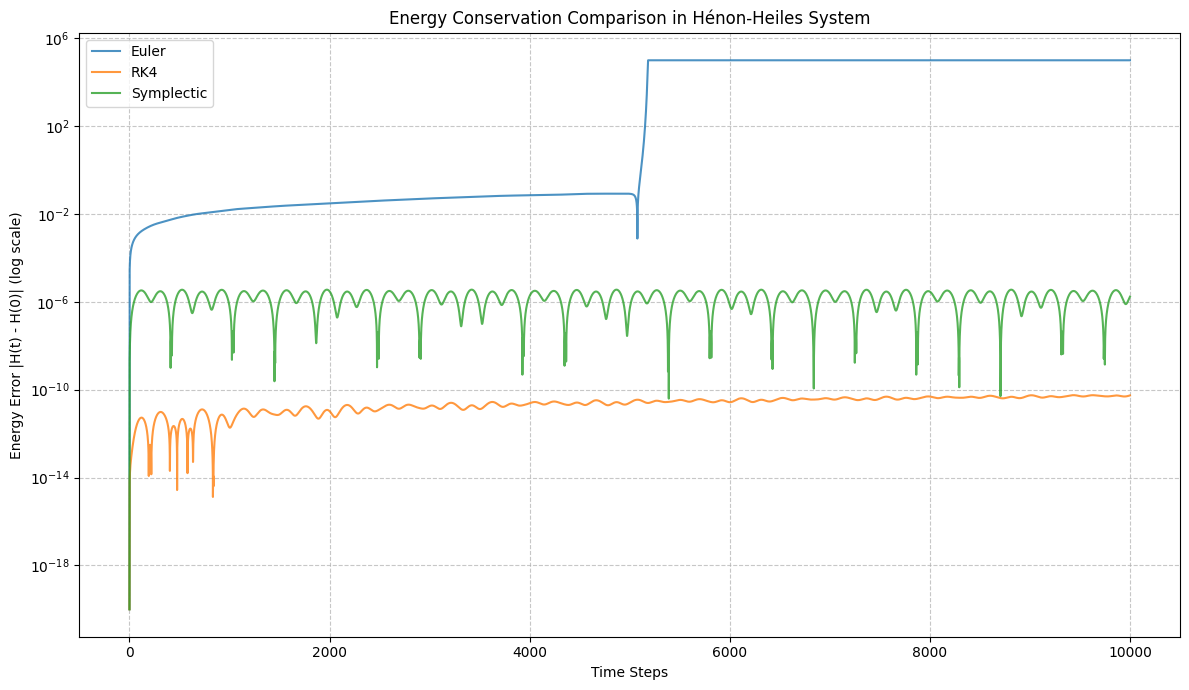

In [6]:
plt.figure(figsize=(12, 7))

# Replace 0 values with a very small number for log plotting
energy_errors_euler_plot = np.where(energy_errors_euler == 0, 1e-20, energy_errors_euler)
energy_errors_rk4_plot = np.where(energy_errors_rk4 == 0, 1e-20, energy_errors_rk4)
energy_errors_symplectic_plot = np.where(energy_errors_symplectic == 0, 1e-20, energy_errors_symplectic)

plt.plot(time_points, energy_errors_euler_plot, label='Euler', alpha=0.8)
plt.plot(time_points, energy_errors_rk4_plot, label='RK4', alpha=0.8)
plt.plot(time_points, energy_errors_symplectic_plot, label='Symplectic', alpha=0.8)

plt.yscale('log') # Set y-axis to log scale
plt.xlabel('Time Steps')
plt.ylabel('Energy Error |H(t) - H(0)| (log scale)')
plt.title('Energy Conservation Comparison in Hénon-Heiles System')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
# Save the generated plot
plt.savefig('energy_conservation_comparison.png', bbox_inches='tight', dpi=300)
print('Plot saved as energy_conservation_comparison.png')

Plot saved as energy_conservation_comparison.png


<Figure size 640x480 with 0 Axes>

The plot has been saved as `energy_conservation_comparison.png`. You can now use this image in your `executive_summary.md` file.

Here's what the results indicate:

- Euler Method (diverged at timestep 5182): As expected, the Euler method shows a rapid increase in energy error, diverging relatively quickly. This is characteristic of explicit non-symplectic integrators when applied to Hamiltonian systems over long times.
- Runge-Kutta 4 (RK4, ran for full 10,000 timesteps): The RK4 method provides significantly better energy conservation than Euler. Its energy error remains much smaller, although you can observe a gradual, but slow, drift in energy over the entire simulation period.
- Symplectic Integrator (ran for full 10,000 timesteps): The symplectic integrator demonstrates the best energy conservation among the three. Its energy error remains bounded and oscillates around a very small value throughout the simulation. This highlights the advantage of symplectic integrators in preserving the long-term energy properties of Hamiltonian systems, even though individual steps might not be as accurate as RK4 in terms of local error.